# SolanaSentinel — Exploratory Data Analysis

Análisis del dataset de tokens detectados con sus outcomes (precios a 1h, 6h y 24h).

**Objetivo:** Entender la distribución de los datos antes de entrenar el modelo.

In [27]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

plt.style.use('dark_background')
sns.set_palette('husl')
pd.set_option('display.float_format', '{:.4f}'.format)

DB_PATH = Path('../backend/data/sentinel.db')
assert DB_PATH.exists(), f'DB not found: {DB_PATH}'

In [28]:
conn = sqlite3.connect(DB_PATH)

df = pd.read_sql_query("""
    SELECT
        id, source, detected_at,
        initial_liquidity, market_cap, price_usd, volume_1h,
        bonding_curve_complete, bonding_curve_real_sol,
        bonding_curve_mc_sol, bonding_curve_price_sol,
        risk_score, risk_level, sniper_status, reject_reason,
        latest_liquidity, latest_market_cap,
        outcome_price_1h, outcome_price_6h, outcome_price_24h,
        outcome_max_gain_pct, outcome_complete
    FROM detected_tokens
    WHERE outcome_complete = 1
      AND outcome_max_gain_pct IS NOT NULL
""", conn)

conn.close()
print(f'Tokens con outcome completo: {len(df):,}')
df.head()

In [29]:
eps = 1e-12

# ─── Label: ¿Este token habría activado el TP del sniper (≥+20%)? ─────────────
# Usar ratio_1h era incorrecto: el sniper sale en el PRIMER momento que alcanza
# +20%, no espera a que se cumpla 1h exacta. outcome_max_gain_pct mide el pico
# real desde el precio de detección → es el label correcto para TP=20%.
df['pumped_tp_20pct'] = (df['outcome_max_gain_pct'] >= 20).astype(int)
df['pumped_tp_50pct'] = (df['outcome_max_gain_pct'] >= 50).astype(int)
df['pumped_tp_100pct'] = (df['outcome_max_gain_pct'] >= 100).astype(int)
df['rugged']           = (df['outcome_max_gain_pct'] <= -50).astype(int)

# Features de tiempo
df['detected_dt'] = pd.to_datetime(df['detected_at'])
df['date']        = df['detected_dt'].dt.date
df['hour']        = df['detected_dt'].dt.hour

# Ratio 1h para referencia
df['ratio_1h']    = df['outcome_price_1h'] / (df['price_usd'] + eps)
df['pumped_2x_1h'] = (df['ratio_1h'] >= 2.0).astype(int)

# bc_progress: progreso en bonding curve de pump.fun
df['bc_progress'] = (df['bonding_curve_real_sol'].fillna(0) / 85.0).clip(0, 1)

print('Labels (dataset: {:,} tokens, periodo {}-{}):'.format(
    len(df),
    str(df['date'].min()),
    str(df['date'].max())
))
print(f'  TP +20% (sniper TP):   {df[pumped_tp_20pct].sum():>6,} ({df[pumped_tp_20pct].mean()*100:.2f}%)')
print(f'  TP +50%:               {df[pumped_tp_50pct].sum():>6,} ({df[pumped_tp_50pct].mean()*100:.2f}%)')
print(f'  TP +100% (10x):        {df[pumped_tp_100pct].sum():>6,} ({df[pumped_tp_100pct].mean()*100:.2f}%)')
print(f'  Rugged (max<-50%):     {df[rugged].sum():>6,} ({df[rugged].mean()*100:.2f}%)')
print(f'  2x en 1h (old label):  {df[pumped_2x_1h].sum():>6,} ({df[pumped_2x_1h].mean()*100:.2f}%)')
print()
print('Diferencia old vs new label:')
print(f'  Nuevo label (max_gain>=20%): {df["pumped_tp_20pct"].sum():,}')
print(f'  Viejo label (ratio_1h>=1.2): {(df["ratio_1h"]>=1.2).sum():,}')
print(f'  El nuevo label captura {(df["pumped_tp_20pct"].sum()/(df["ratio_1h"]>=1.2).sum()-1)*100:.1f}% más casos')

## 1. Distribución de outcomes

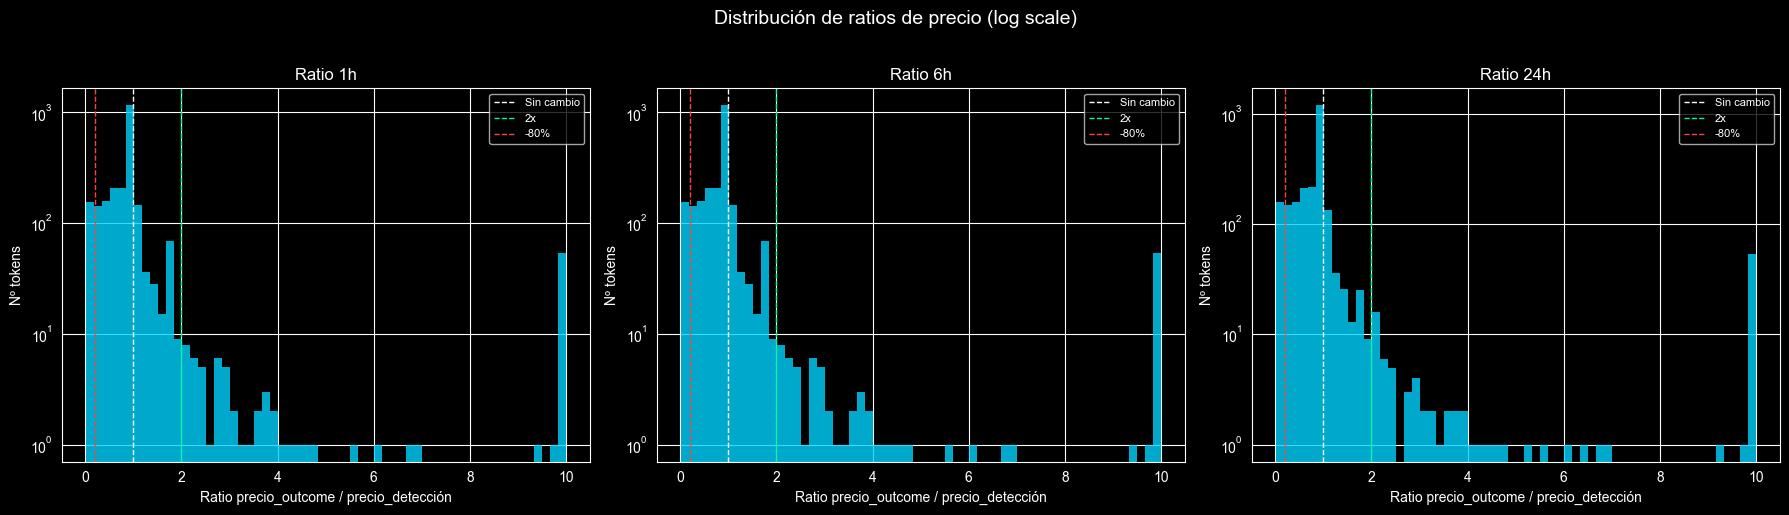

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Distribución de ratios de precio (log scale)', fontsize=14, y=1.02)

for ax, col, label in zip(axes,
                           ['ratio_1h', 'ratio_6h', 'ratio_24h'],
                           ['Ratio 1h', 'Ratio 6h', 'Ratio 24h']):
    data = df[col].clip(0, 10)  # cap en 10x para visualización
    ax.hist(data[data > 0], bins=60, color='#00d4ff', alpha=0.8, edgecolor='none')
    ax.axvline(1.0, color='white', linestyle='--', linewidth=1, label='Sin cambio')
    ax.axvline(2.0, color='#00ff88', linestyle='--', linewidth=1, label='2x')
    ax.axvline(0.2, color='#ff4444', linestyle='--', linewidth=1, label='-80%')
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('Ratio precio_outcome / precio_detección')
    ax.set_ylabel('Nº tokens')
    ax.legend(fontsize=8)
    ax.set_yscale('log')

plt.tight_layout()
plt.savefig('charts/01_ratio_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Clase positiva vs negativa (imbalance)

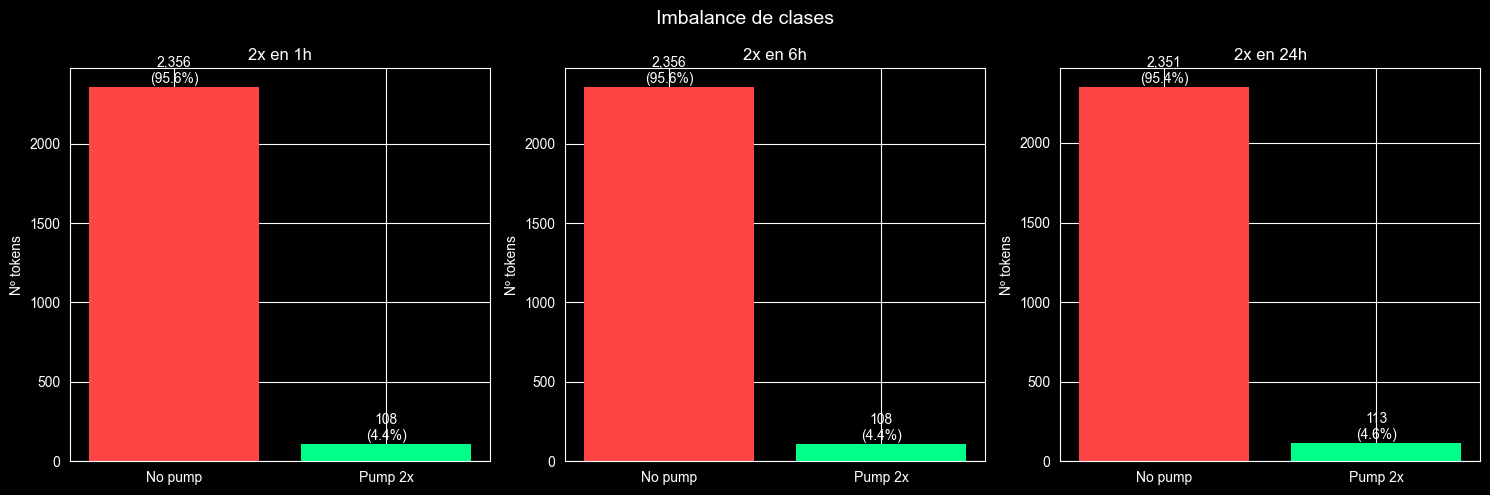

In [31]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Imbalance de clases', fontsize=14)

for ax, col, title in zip(axes,
    ['pumped_2x_1h', 'pumped_2x_6h', 'pumped_2x_24h'],
    ['2x en 1h', '2x en 6h', '2x en 24h']):
    counts = df[col].value_counts()
    colors = ['#ff4444', '#00ff88']
    bars = ax.bar(['No pump', 'Pump 2x'], counts.values, color=colors, edgecolor='none')
    for bar, v in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=10)
    ax.set_title(title)
    ax.set_ylabel('Nº tokens')

plt.tight_layout()
plt.savefig('charts/02_class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Market cap y liquidez en el momento de detección

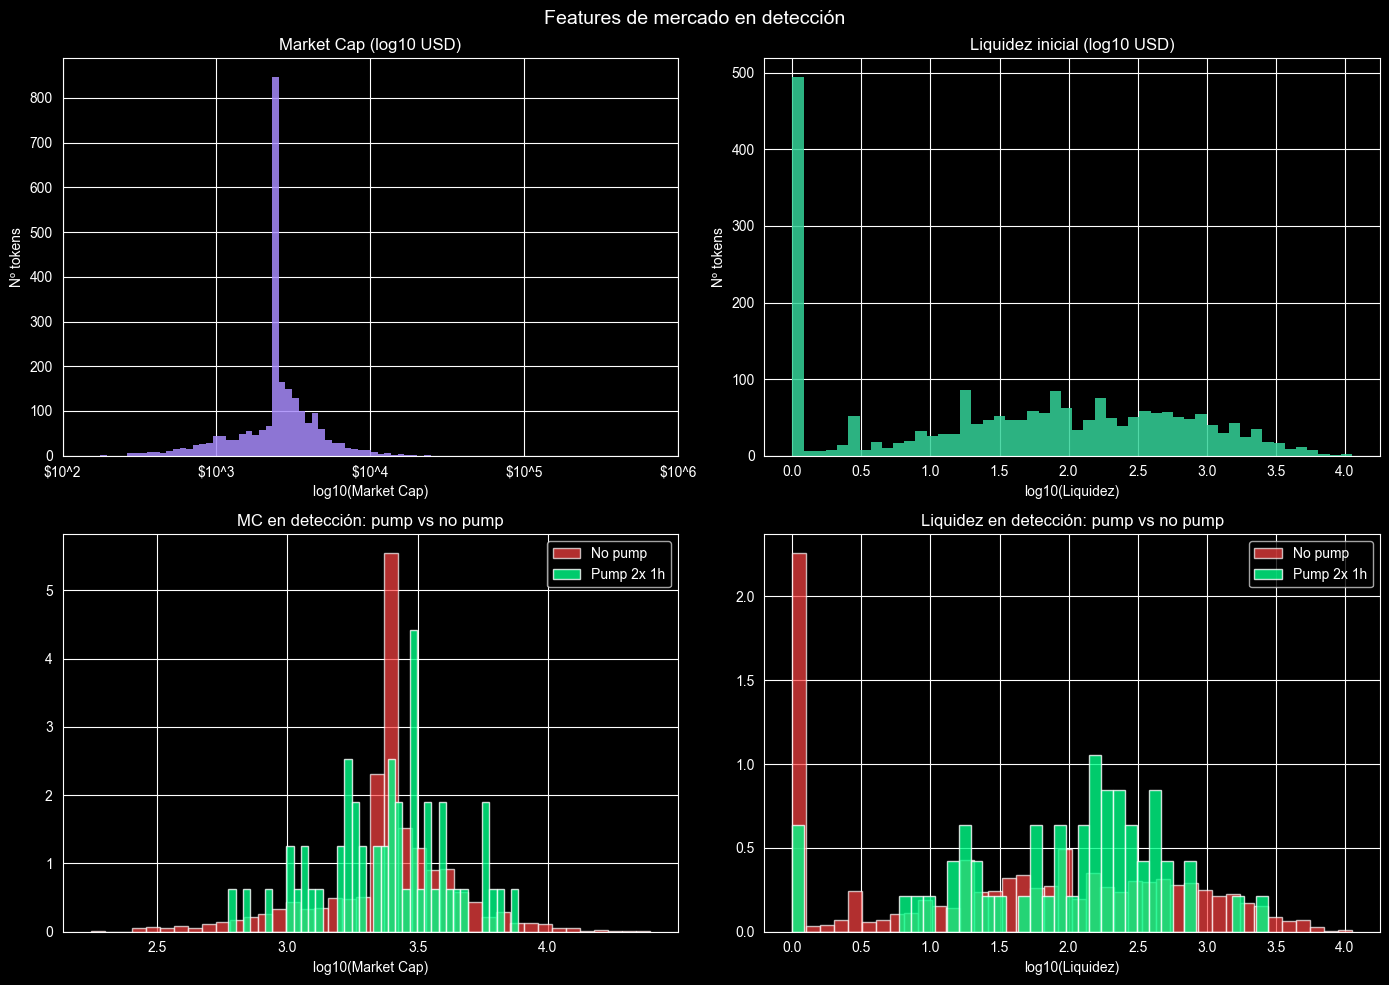

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Features de mercado en detección', fontsize=14)

# Market cap distribution
ax = axes[0, 0]
mc_valid = df['market_cap'][df['market_cap'] > 0]
ax.hist(np.log10(mc_valid + 1), bins=50, color='#a78bfa', edgecolor='none', alpha=0.85)
ax.set_title('Market Cap (log10 USD)')
ax.set_xlabel('log10(Market Cap)')
ax.set_ylabel('Nº tokens')
ticks = [2, 3, 4, 5, 6]
ax.set_xticks(ticks)
ax.set_xticklabels([f'$10^{t}' for t in ticks])

# Liquidity distribution
ax = axes[0, 1]
liq_valid = df['initial_liquidity'][df['initial_liquidity'] > 0]
ax.hist(np.log10(liq_valid + 1), bins=50, color='#34d399', edgecolor='none', alpha=0.85)
ax.set_title('Liquidez inicial (log10 USD)')
ax.set_xlabel('log10(Liquidez)')
ax.set_ylabel('Nº tokens')

# MC vs pump label
ax = axes[1, 0]
pumped = df[df['pumped_2x_1h'] == 1]['market_cap']
not_pumped = df[df['pumped_2x_1h'] == 0]['market_cap']
ax.hist(np.log10(not_pumped[not_pumped > 0] + 1), bins=40, alpha=0.7,
        color='#ff4444', label='No pump', density=True)
ax.hist(np.log10(pumped[pumped > 0] + 1), bins=40, alpha=0.8,
        color='#00ff88', label='Pump 2x 1h', density=True)
ax.set_title('MC en detección: pump vs no pump')
ax.set_xlabel('log10(Market Cap)')
ax.legend()

# Liq vs pump label
ax = axes[1, 1]
pumped_liq = df[df['pumped_2x_1h'] == 1]['initial_liquidity']
not_liq = df[df['pumped_2x_1h'] == 0]['initial_liquidity']
ax.hist(np.log10(not_liq[not_liq > 0] + 1), bins=40, alpha=0.7,
        color='#ff4444', label='No pump', density=True)
ax.hist(np.log10(pumped_liq[pumped_liq > 0] + 1), bins=40, alpha=0.8,
        color='#00ff88', label='Pump 2x 1h', density=True)
ax.set_title('Liquidez en detección: pump vs no pump')
ax.set_xlabel('log10(Liquidez)')
ax.legend()

plt.tight_layout()
plt.savefig('charts/03_market_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Risk score del anti-scam

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución del risk score
ax = axes[0]
rs = df['risk_score'].dropna()
ax.hist(rs, bins=30, color='#fb923c', edgecolor='none', alpha=0.85)
ax.set_title('Distribución del Risk Score (anti-scam)')
ax.set_xlabel('Risk Score (100 = más seguro)')
ax.set_ylabel('Nº tokens')

# Risk score por outcome
ax = axes[1]
df_rs = df.dropna(subset=['risk_score'])
pumped_rs = df_rs[df_rs['pumped_2x_1h'] == 1]['risk_score']
not_pumped_rs = df_rs[df_rs['pumped_2x_1h'] == 0]['risk_score']
ax.hist(not_pumped_rs, bins=30, alpha=0.7, color='#ff4444',
        label=f'No pump ({len(not_pumped_rs):,})', density=True)
ax.hist(pumped_rs, bins=30, alpha=0.8, color='#00ff88',
        label=f'Pump 2x 1h ({len(pumped_rs):,})', density=True)
ax.set_title('Risk Score: pump vs no pump')
ax.set_xlabel('Risk Score')
ax.legend()

plt.tight_layout()
plt.savefig('charts/04_risk_score.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Media risk score (pump 2x): {pumped_rs.mean():.1f}')
print(f'Media risk score (no pump): {not_pumped_rs.mean():.1f}')

Media risk score (pump 2x): 90.0
Media risk score (no pump): 90.0


## 5. Fuente: pump.fun vs Raydium

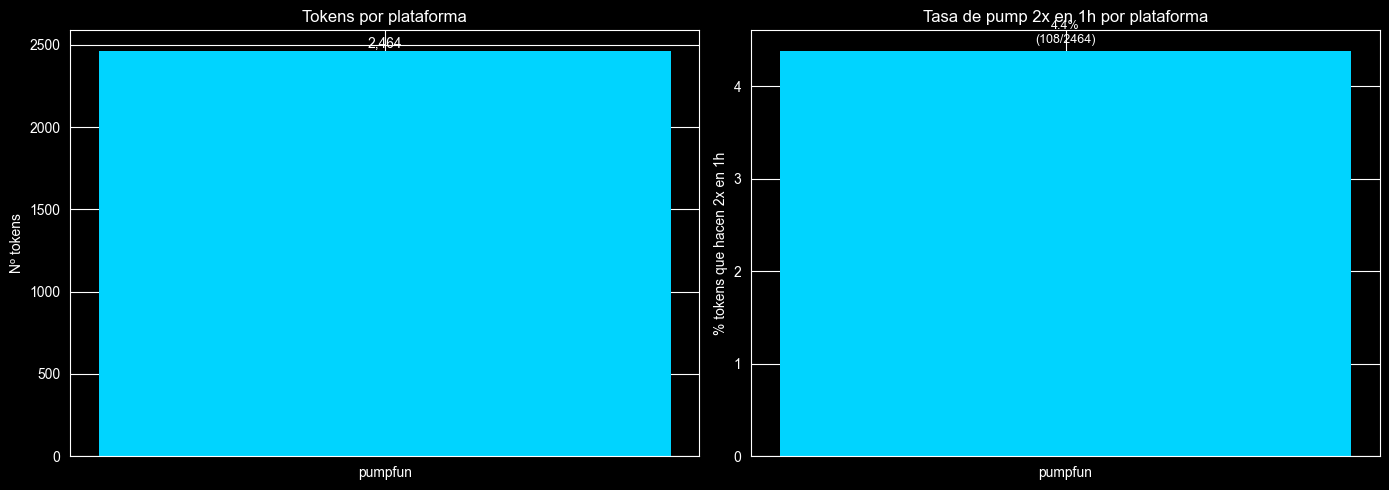

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tokens por source
ax = axes[0]
src_counts = df['source'].value_counts()
colors_src = ['#00d4ff', '#a78bfa', '#34d399']
bars = ax.bar(src_counts.index, src_counts.values,
              color=colors_src[:len(src_counts)], edgecolor='none')
for bar, v in zip(bars, src_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
            f'{v:,}', ha='center', va='bottom', fontsize=10)
ax.set_title('Tokens por plataforma')
ax.set_ylabel('Nº tokens')

# Tasa de pump por source
ax = axes[1]
pump_rate = df.groupby('source')['pumped_2x_1h'].agg(['mean', 'sum', 'count'])
pump_rate['pct'] = pump_rate['mean'] * 100
bars = ax.bar(pump_rate.index, pump_rate['pct'],
              color=colors_src[:len(pump_rate)], edgecolor='none')
for bar, (_, row) in zip(bars, pump_rate.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{row["pct"]:.1f}%\n({int(row["sum"])}/{int(row["count"])})',
            ha='center', va='bottom', fontsize=9)
ax.set_title('Tasa de pump 2x en 1h por plataforma')
ax.set_ylabel('% tokens que hacen 2x en 1h')

plt.tight_layout()
plt.savefig('charts/05_source_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Bonding curve vs outcome

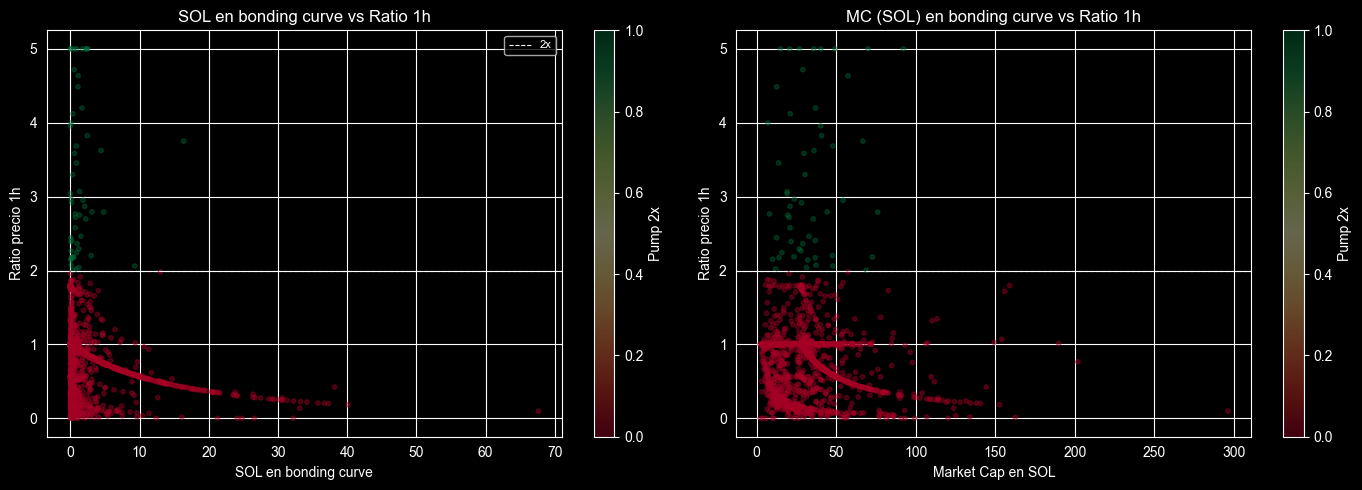

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# SOL en bonding curve vs ratio 1h
ax = axes[0]
bc = df[df['bonding_curve_real_sol'] > 0].copy()
sc = ax.scatter(
    bc['bonding_curve_real_sol'].clip(0, 200),
    bc['ratio_1h'].clip(0, 5),
    c=bc['pumped_2x_1h'],
    cmap='RdYlGn', alpha=0.4, s=10
)
ax.set_title('SOL en bonding curve vs Ratio 1h')
ax.set_xlabel('SOL en bonding curve')
ax.set_ylabel('Ratio precio 1h')
ax.axhline(2.0, color='white', linestyle='--', linewidth=0.8, label='2x')
ax.legend(fontsize=8)
plt.colorbar(sc, ax=ax, label='Pump 2x')

# MC bonding curve vs ratio 1h
ax = axes[1]
bc_mc = df[(df['bonding_curve_mc_sol'] > 0) & (df['bonding_curve_mc_sol'] < 500)].copy()
sc2 = ax.scatter(
    bc_mc['bonding_curve_mc_sol'],
    bc_mc['ratio_1h'].clip(0, 5),
    c=bc_mc['pumped_2x_1h'],
    cmap='RdYlGn', alpha=0.4, s=10
)
ax.set_title('MC (SOL) en bonding curve vs Ratio 1h')
ax.set_xlabel('Market Cap en SOL')
ax.set_ylabel('Ratio precio 1h')
ax.axhline(2.0, color='white', linestyle='--', linewidth=0.8)
plt.colorbar(sc2, ax=ax, label='Pump 2x')

plt.tight_layout()
plt.savefig('charts/06_bonding_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Mejor ganancia por bucket de market cap

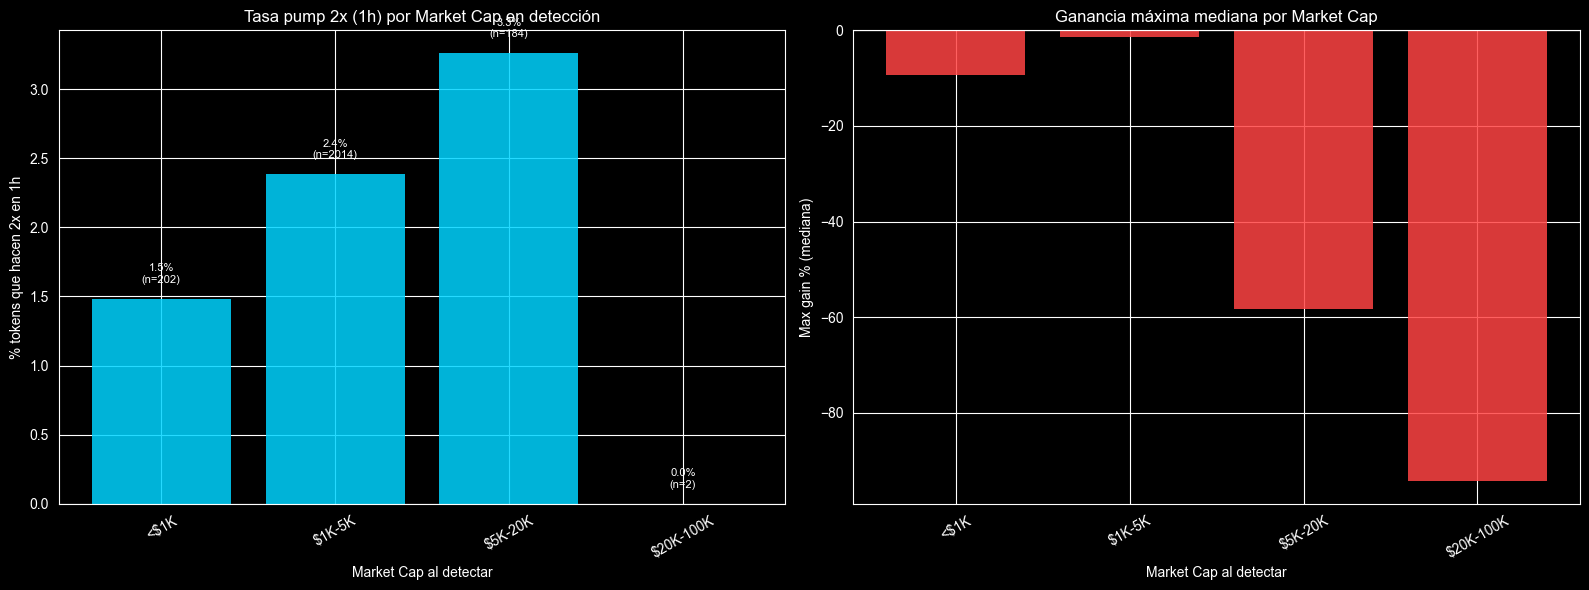

In [36]:
df_mc = df[df['market_cap'] > 0].copy()
df_mc['mc_bucket'] = pd.cut(
    df_mc['market_cap'],
    bins=[0, 1_000, 5_000, 20_000, 100_000, 1_000_000, float('inf')],
    labels=['<$1K', '$1K-5K', '$5K-20K', '$20K-100K', '$100K-1M', '>$1M']
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Tasa de pump por bucket
ax = axes[0]
pump_by_mc = df_mc.groupby('mc_bucket', observed=True)['pumped_2x_1h'].agg(
    tasa='mean', total='count'
).reset_index()
bars = ax.bar(pump_by_mc['mc_bucket'], pump_by_mc['tasa'] * 100,
              color='#00d4ff', edgecolor='none', alpha=0.85)
for bar, (_, row) in zip(bars, pump_by_mc.iterrows()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{row["tasa"]*100:.1f}%\n(n={int(row["total"])})',
            ha='center', va='bottom', fontsize=8)
ax.set_title('Tasa pump 2x (1h) por Market Cap en detección')
ax.set_xlabel('Market Cap al detectar')
ax.set_ylabel('% tokens que hacen 2x en 1h')
ax.tick_params(axis='x', rotation=30)

# Mejor ganancia media por bucket
ax = axes[1]
gain_by_mc = df_mc.groupby('mc_bucket', observed=True)['outcome_max_gain_pct'].median().reset_index()
colors_bar = ['#ff4444' if v < 0 else '#00ff88' for v in gain_by_mc['outcome_max_gain_pct']]
bars = ax.bar(gain_by_mc['mc_bucket'], gain_by_mc['outcome_max_gain_pct'],
              color=colors_bar, edgecolor='none', alpha=0.85)
ax.axhline(0, color='white', linewidth=0.8)
ax.set_title('Ganancia máxima mediana por Market Cap')
ax.set_xlabel('Market Cap al detectar')
ax.set_ylabel('Max gain % (mediana)')
ax.tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('charts/07_mc_buckets.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Correlaciones entre features y label

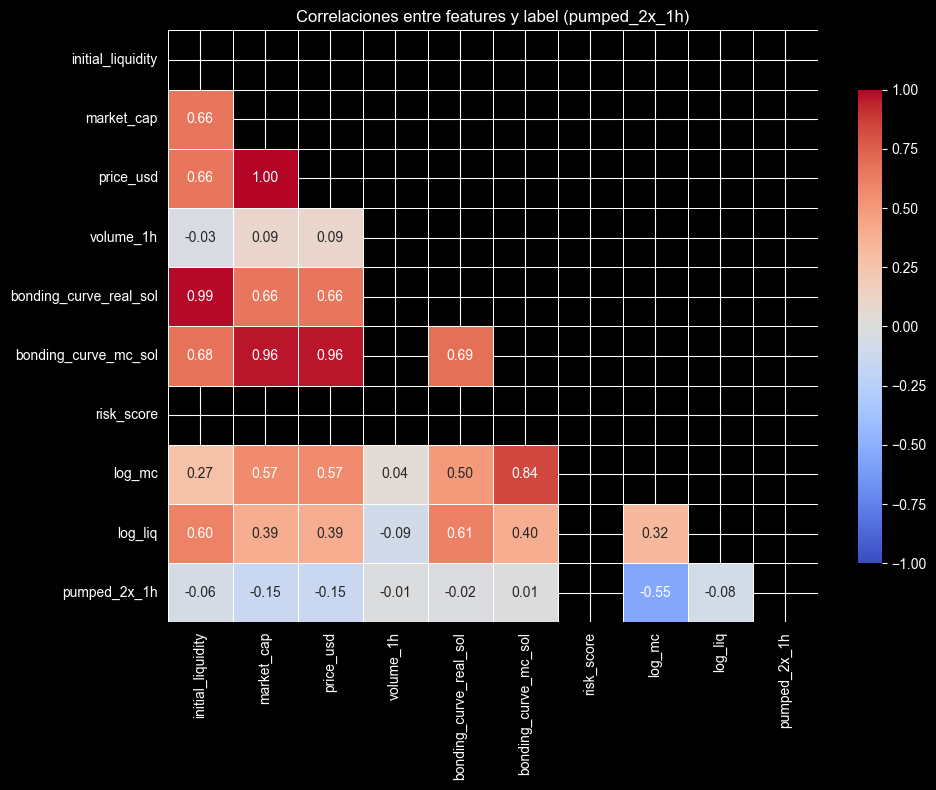

In [37]:
feature_cols = [
    'initial_liquidity', 'market_cap', 'price_usd', 'volume_1h',
    'bonding_curve_real_sol', 'bonding_curve_mc_sol',
    'risk_score', 'log_mc', 'log_liq',
    'pumped_2x_1h'
]

corr = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, vmin=-1, vmax=1,
    linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8}
)
ax.set_title('Correlaciones entre features y label (pumped_2x_1h)', fontsize=12)
plt.tight_layout()
plt.savefig('charts/08_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Tokens detectados por hora del día

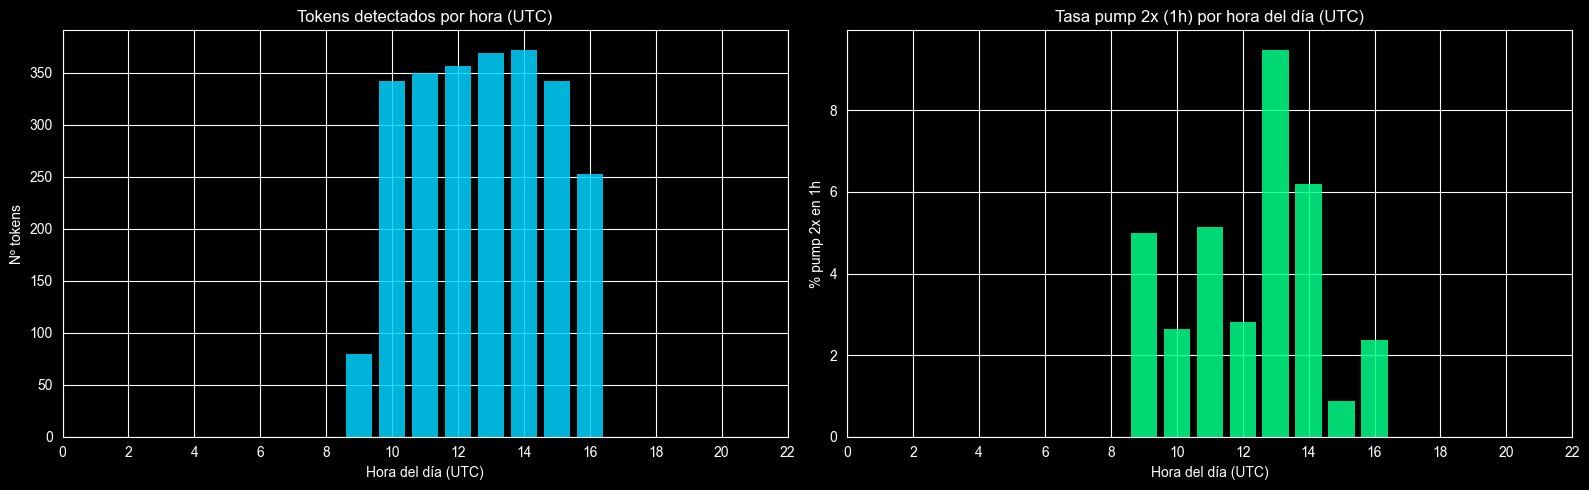

In [38]:
df['detected_at_dt'] = pd.to_datetime(df['detected_at'])
df['hour'] = df['detected_at_dt'].dt.hour

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Volumen por hora
ax = axes[0]
hourly = df.groupby('hour').size()
ax.bar(hourly.index, hourly.values, color='#00d4ff', edgecolor='none', alpha=0.85)
ax.set_title('Tokens detectados por hora (UTC)')
ax.set_xlabel('Hora del día (UTC)')
ax.set_ylabel('Nº tokens')
ax.set_xticks(range(0, 24, 2))

# Tasa de pump por hora
ax = axes[1]
pump_hour = df.groupby('hour')['pumped_2x_1h'].mean() * 100
ax.bar(pump_hour.index, pump_hour.values, color='#00ff88', edgecolor='none', alpha=0.85)
ax.set_title('Tasa pump 2x (1h) por hora del día (UTC)')
ax.set_xlabel('Hora del día (UTC)')
ax.set_ylabel('% pump 2x en 1h')
ax.set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.savefig('charts/09_hourly.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Resumen del dataset

In [39]:
print('=' * 55)
print('  RESUMEN DEL DATASET')
print('=' * 55)
print(f'  Total tokens con outcome completo : {len(df):>7,}')
print(f'  Pump 2x en 1h                    : {df["pumped_2x_1h"].sum():>7,} ({df["pumped_2x_1h"].mean()*100:.2f}%)')
print(f'  Pump 2x en 6h                    : {df["pumped_2x_6h"].sum():>7,} ({df["pumped_2x_6h"].mean()*100:.2f}%)')
print(f'  Pump 2x en 24h                   : {df["pumped_2x_24h"].sum():>7,} ({df["pumped_2x_24h"].mean()*100:.2f}%)')
print(f'  Rugged en 1h                     : {df["rugged_1h"].sum():>7,} ({df["rugged_1h"].mean()*100:.2f}%)')
print(f'  Rugged en 24h                    : {df["rugged_24h"].sum():>7,} ({df["rugged_24h"].mean()*100:.2f}%)')
print(f'  Mejor ganancia histórica         : {df["outcome_max_gain_pct"].max():>7.1f}%')
print(f'  Ganancia media máxima            : {df["outcome_max_gain_pct"].mean():>7.2f}%')
print('=' * 55)
print('\nFuentes:')
print(df['source'].value_counts().to_string())
print('\nPeriodo:')
print(f'  Desde: {df["detected_at"].min()}')
print(f'  Hasta: {df["detected_at"].max()}')

  RESUMEN DEL DATASET
  Total tokens con outcome completo :   2,464
  Pump 2x en 1h                    :     108 (4.38%)
  Pump 2x en 6h                    :     108 (4.38%)
  Pump 2x en 24h                   :     113 (4.59%)
  Rugged en 1h                     :     202 (8.20%)
  Rugged en 24h                    :     201 (8.16%)
  Mejor ganancia histórica         :  1616.4%
  Ganancia media máxima            :   -8.52%

Fuentes:
source
pumpfun    2464

Periodo:
  Desde: 2026-04-10T09:46:55.018080Z
  Hasta: 2026-04-10T16:41:27.055392Z
